# aFRR Energy Price EDA (Regelleistung)

This notebook compares marginal vs average aFRR **energy** prices and recommends a modeling target.

It supports two schemas:
- Raw regelleistung names: `GERMANY_MARGINAL_ENERGY_PRICE_[EUR/MWh]`, `GERMANY_AVERAGE_ENERGY_PRICE_[EUR/MWh]`
- Pipeline names: `afrr_activation_marginal_price_pos/neg`, `afrr_activation_avg_price_pos/neg`


In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)


polars.config.Config

In [2]:
CANDIDATE_INPUTS = [
    Path('data/raw/regelleistung.parquet'),
    Path('../data/raw/regelleistung.parquet'),
    Path('data/processed/all_data.parquet'),
    Path('../data/processed/all_data.parquet'),
]
INPUT_PATH = next((str(p) for p in CANDIDATE_INPUTS if p.exists()), None)
if INPUT_PATH is None:
    raise FileNotFoundError('Set INPUT_PATH manually to an existing parquet file.')

EXTREME_ABS_THRESHOLD = 90000.0

print('INPUT_PATH =', INPUT_PATH)


INPUT_PATH = ../data/raw/regelleistung.parquet


In [3]:
df = pl.read_parquet(INPUT_PATH)
print(f'Loaded rows: {df.height:,}')
print(f'Loaded cols: {len(df.columns)}')


Loaded rows: 44,571
Loaded cols: 12


In [4]:
def _get_activation_expr(cols: list[str]) -> pl.Expr | None:
    if 'afrr_activated_mwh' in cols:
        return pl.col('afrr_activated_mwh').cast(pl.Float64)
    if 'afrr_activated_mwh_pos' in cols and 'afrr_activated_mwh_neg' in cols:
        return (pl.col('afrr_activated_mwh_pos').cast(pl.Float64).abs() + pl.col('afrr_activated_mwh_neg').cast(pl.Float64).abs())
    if 'activated_energy_mwh' in cols:
        return pl.col('activated_energy_mwh').cast(pl.Float64)
    if 'GERMANY_ACTIVATED_ENERGY_[MWh]' in cols:
        return pl.col('GERMANY_ACTIVATED_ENERGY_[MWh]').cast(pl.Float64)
    return None


def build_analysis_frame(df: pl.DataFrame) -> pl.DataFrame:
    cols = df.columns
    act_expr = _get_activation_expr(cols)

    # Case A: raw regelleistung layout (single marginal/average + direction)
    if (
        'GERMANY_MARGINAL_ENERGY_PRICE_[EUR/MWh]' in cols
        and 'GERMANY_AVERAGE_ENERGY_PRICE_[EUR/MWh]' in cols
    ):
        dir_col = next((c for c in ['DIRECTION', 'direction', 'Richtung', 'richtung'] if c in cols), None)
        if dir_col is None:
            raise ValueError('Direction column missing for raw price schema.')
        out = df.select([
            pl.col('GERMANY_MARGINAL_ENERGY_PRICE_[EUR/MWh]').cast(pl.Float64).alias('marginal_price'),
            pl.col('GERMANY_AVERAGE_ENERGY_PRICE_[EUR/MWh]').cast(pl.Float64).alias('average_price'),
            pl.col(dir_col).cast(pl.Utf8).str.to_lowercase().alias('direction'),
            (act_expr.alias('activation_mwh') if act_expr is not None else pl.lit(None).cast(pl.Float64).alias('activation_mwh')),
        ])
        out = out.with_columns(
            pl.when(pl.col('direction').str.contains('pos|up|positive')).then(pl.lit('pos'))
            .when(pl.col('direction').str.contains('neg|down|negative')).then(pl.lit('neg'))
            .otherwise(None)
            .alias('direction')
        ).filter(pl.col('direction').is_not_null())
        return out

    # Case B: pipeline layout (split pos/neg columns)
    req = [
        'afrr_activation_avg_price_pos',
        'afrr_activation_avg_price_neg',
        'afrr_activation_marginal_price_pos',
        'afrr_activation_marginal_price_neg',
    ]
    missing = [c for c in req if c not in cols]
    if missing:
        raise ValueError(
            'Missing required columns for split-schema analysis: ' + str(missing) + '\n'
            + 'Run fetch_regelleistung again after the latest patch to include marginal price columns.'
        )

    base_cols = []
    if 'timestamp_utc' in cols:
        base_cols.append('timestamp_utc')
    elif 'timestamp' in cols:
        base_cols.append('timestamp')

    pos = df.select(
        [pl.col(c) for c in base_cols] + [
            pl.col('afrr_activation_marginal_price_pos').cast(pl.Float64).alias('marginal_price'),
            pl.col('afrr_activation_avg_price_pos').cast(pl.Float64).alias('average_price'),
            pl.lit('pos').alias('direction'),
            (act_expr.alias('activation_mwh') if act_expr is not None else pl.lit(None).cast(pl.Float64).alias('activation_mwh')),
        ]
    )
    neg = df.select(
        [pl.col(c) for c in base_cols] + [
            pl.col('afrr_activation_marginal_price_neg').cast(pl.Float64).alias('marginal_price'),
            pl.col('afrr_activation_avg_price_neg').cast(pl.Float64).alias('average_price'),
            pl.lit('neg').alias('direction'),
            (act_expr.alias('activation_mwh') if act_expr is not None else pl.lit(None).cast(pl.Float64).alias('activation_mwh')),
        ]
    )
    return pl.concat([pos, neg], how='vertical').drop_nulls(['marginal_price', 'average_price'])


a = build_analysis_frame(df)
print(a.head())
print('Analysis rows:', a.height)


shape: (5, 5)
┌─────────────────────────┬────────────────┬───────────────┬───────────┬────────────────┐
│ timestamp_utc           ┆ marginal_price ┆ average_price ┆ direction ┆ activation_mwh │
│ ---                     ┆ ---            ┆ ---           ┆ ---       ┆ ---            │
│ datetime[μs, UTC]       ┆ f64            ┆ f64           ┆ str       ┆ f64            │
╞═════════════════════════╪════════════════╪═══════════════╪═══════════╪════════════════╡
│ 2020-12-01 00:00:00 UTC ┆ 23800.0        ┆ 2733.73       ┆ pos       ┆ null           │
│ 2020-12-01 01:00:00 UTC ┆ 23800.0        ┆ 2733.73       ┆ pos       ┆ null           │
│ 2020-12-01 02:00:00 UTC ┆ 23800.0        ┆ 2733.73       ┆ pos       ┆ null           │
│ 2020-12-01 03:00:00 UTC ┆ 11519.16       ┆ 3664.63       ┆ pos       ┆ null           │
│ 2020-12-01 04:00:00 UTC ┆ 11519.16       ┆ 3664.63       ┆ pos       ┆ null           │
└─────────────────────────┴────────────────┴───────────────┴───────────┴──────────────

Outlier check:
 - marginal extremes: 2,336/89,142 (2.621%)
 - average  extremes: 0/89,142 (0.000%)


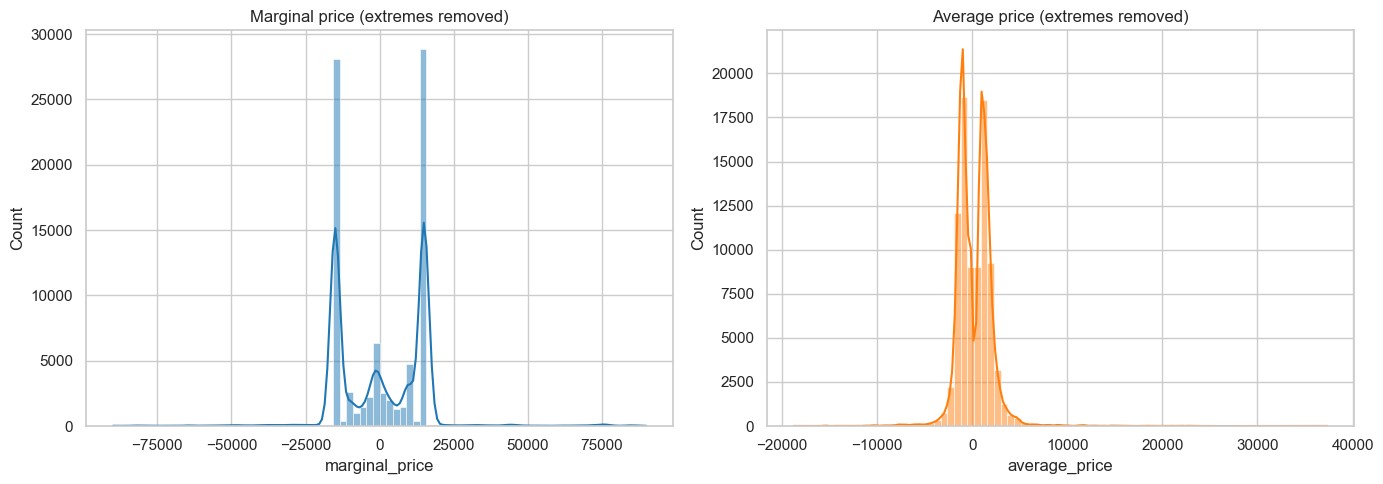

In [5]:
# 1) Outlier / regulatory-bound detection
n = a.height
ext_marg = a.filter(pl.col('marginal_price').abs() > EXTREME_ABS_THRESHOLD).height
ext_avg = a.filter(pl.col('average_price').abs() > EXTREME_ABS_THRESHOLD).height

print('Outlier check:')
print(f' - marginal extremes: {ext_marg:,}/{n:,} ({100*ext_marg/max(n,1):.3f}%)')
print(f' - average  extremes: {ext_avg:,}/{n:,} ({100*ext_avg/max(n,1):.3f}%)')

plot_df = a.filter(
    (pl.col('marginal_price').abs() <= EXTREME_ABS_THRESHOLD) &
    (pl.col('average_price').abs() <= EXTREME_ABS_THRESHOLD)
).select(['marginal_price', 'average_price']).to_pandas()

fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.histplot(plot_df['marginal_price'], bins=80, kde=True, ax=ax[0], color='tab:blue')
ax[0].set_title('Marginal price (extremes removed)')
sns.histplot(plot_df['average_price'], bins=80, kde=True, ax=ax[1], color='tab:orange')
ax[1].set_title('Average price (extremes removed)')
plt.tight_layout()
plt.show()


In [6]:
# 2) Market reality check
pos = a.filter(pl.col('direction') == 'pos')
neg = a.filter(pl.col('direction') == 'neg')
pos_viol = pos.filter(pl.col('marginal_price') < pl.col('average_price')).height
neg_viol = neg.filter(pl.col('marginal_price') > pl.col('average_price')).height

print('Rule check:')
print(f' - POS marginal>=average violations: {pos_viol:,}/{pos.height:,} ({100*pos_viol/max(pos.height,1):.3f}%)')
print(f' - NEG marginal<=average violations: {neg_viol:,}/{neg.height:,} ({100*neg_viol/max(neg.height,1):.3f}%)')


Rule check:
 - POS marginal>=average violations: 0/44,571 (0.000%)
 - NEG marginal<=average violations: 0/44,571 (0.000%)


In [7]:
# 3) Zero-activation correlation for extreme marginal prices
if a['activation_mwh'].null_count() == a.height:
    print('Activation energy not available in this file -> skip correlation test.')
else:
    ex = a.filter(pl.col('marginal_price').abs() > EXTREME_ABS_THRESHOLD)
    ex_total = ex.height
    ex_zero = ex.filter(pl.col('activation_mwh') == 0).height
    ex_nonzero = ex.filter(pl.col('activation_mwh') != 0).height

    print('Extreme vs activation:')
    print(f' - extreme rows: {ex_total:,}')
    print(f' - zero activation: {ex_zero:,} ({100*ex_zero/max(ex_total,1):.3f}%)')
    print(f' - non-zero activation: {ex_nonzero:,}')


Activation energy not available in this file -> skip correlation test.


In [8]:
# 4) Volatility/usability stats (excluding sentinel-like extremes)
cl = a.filter(
    (pl.col('marginal_price').abs() <= EXTREME_ABS_THRESHOLD) &
    (pl.col('average_price').abs() <= EXTREME_ABS_THRESHOLD)
)
stats = cl.select([
    pl.col('marginal_price').std().alias('marginal_std'),
    pl.col('marginal_price').median().alias('marginal_median'),
    pl.col('marginal_price').quantile(0.95).alias('marginal_p95'),
    pl.col('average_price').std().alias('average_std'),
    pl.col('average_price').median().alias('average_median'),
    pl.col('average_price').quantile(0.95).alias('average_p95'),
])
print(stats)


shape: (1, 6)
┌──────────────┬─────────────────┬──────────────┬─────────────┬────────────────┬─────────────┐
│ marginal_std ┆ marginal_median ┆ marginal_p95 ┆ average_std ┆ average_median ┆ average_p95 │
│ ---          ┆ ---             ┆ ---          ┆ ---         ┆ ---            ┆ ---         │
│ f64          ┆ f64             ┆ f64          ┆ f64         ┆ f64            ┆ f64         │
╞══════════════╪═════════════════╪══════════════╪═════════════╪════════════════╪═════════════╡
│ 16269.882518 ┆ -300.0          ┆ 15000.0      ┆ 1955.155721 ┆ -22.36         ┆ 2639.83     │
└──────────────┴─────────────────┴──────────────┴─────────────┴────────────────┴─────────────┘


In [9]:
# 5) Recommendation + cleaning snippet
# Default recommendation for ML target in this setup:
# - use average as stable target
# - keep marginal as auxiliary feature / diagnostic column

print('Recommendation:')
print('- Target y: average_price (volume-weighted, more stable)')
print('- Keep marginal_price as feature/diagnostic for scarcity spikes')

print('\nPolars cleaning snippet (for marginal):')
print(r'''df = df.with_columns(
    pl.when(pl.col("afrr_activation_marginal_price_neg").abs() > 90000)
      .then(
          pl.when(
              (pl.col("afrr_activated_mwh_neg").fill_null(0).abs() == 0)
          ).then(0.0)
           .otherwise(None)
      )
      .otherwise(pl.col("afrr_activation_marginal_price_neg"))
      .alias("cleaned_marginal_price_eur_mwh")
)''')


Recommendation:
- Target y: average_price (volume-weighted, more stable)
- Keep marginal_price as feature/diagnostic for scarcity spikes

Polars cleaning snippet (for marginal):
df = df.with_columns(
    pl.when(pl.col("afrr_activation_marginal_price_neg").abs() > 90000)
      .then(
          pl.when(
              (pl.col("afrr_activated_mwh_neg").fill_null(0).abs() == 0)
          ).then(0.0)
           .otherwise(None)
      )
      .otherwise(pl.col("afrr_activation_marginal_price_neg"))
      .alias("cleaned_marginal_price_eur_mwh")
)


## Data Science vs. Energy Economics (Final Target Definition)

The previous statistical recommendation ("use average price because variance is lower") is **not economically valid** for the German aFRR PICASSO market.

- **Market design reality:** aFRR balancing energy is settled **Pay-As-Cleared**. Activated bids are remunerated at the **marginal clearing price**, not the average accepted price.
- **Implication for modeling/backtesting:** using average price as target would create **fictitious revenues** and bias strategy evaluation.
- **Data issue in marginal price:**
  - Technical sentinel/regulatory placeholder values around `+/-99999` (typically zero activation situations)
  - Real scarcity spikes (e.g., up to `+/-15000`) that are economically real but destabilize MSE-based regression training

### Solution: Two-target design

1. **`y_true` (economically correct, for PnL/backtest):** cleaned marginal price with only technical sentinels neutralized.
2. **`y_train` (ML-stable, for model fitting):** clipped version of `y_true` (here `[-500, 500]`) to reduce extreme-tail dominance in loss.

This keeps **financial realism** in evaluation while improving **training stability**.

In [10]:
# Target engineering for PICASSO pay-as-cleared setup
# Required marginal columns:
# - afrr_activation_marginal_price_pos / neg
# Activation can come from:
# - afrr_activated_mwh_pos/neg (preferred)
# - afrr_activated_mw_pos/neg (fallback; for hourly data treated as MWh equivalent over 1h)

REQ_MARG = [
    'afrr_activation_marginal_price_pos',
    'afrr_activation_marginal_price_neg',
]
missing_marg = [c for c in REQ_MARG if c not in df.columns]
if missing_marg:
    raise ValueError(
        f'Missing required marginal columns: {missing_marg}. '
        'Regenerate regelleistung.parquet with updated fetch_regelleistung.py.'
    )

if {'afrr_activated_mwh_pos', 'afrr_activated_mwh_neg'}.issubset(df.columns):
    act_pos_expr = pl.col('afrr_activated_mwh_pos').cast(pl.Float64)
    act_neg_expr = pl.col('afrr_activated_mwh_neg').cast(pl.Float64)
    activation_source = 'afrr_activated_mwh_pos/neg'
elif {'afrr_activated_mw_pos', 'afrr_activated_mw_neg'}.issubset(df.columns):
    # Fallback when MWh columns are not present in the loaded dataset.
    act_pos_expr = pl.col('afrr_activated_mw_pos').cast(pl.Float64)
    act_neg_expr = pl.col('afrr_activated_mw_neg').cast(pl.Float64)
    activation_source = 'afrr_activated_mw_pos/neg (fallback)'
else:
    # No activation information available: apply sentinel neutralization on extreme values only.
    act_pos_expr = pl.lit(None).cast(pl.Float64)
    act_neg_expr = pl.lit(None).cast(pl.Float64)
    activation_source = 'none'

print(f'Activation source used: {activation_source}')

SENTINEL_ABS = 90000.0
CLIP_LOW = -500.0
CLIP_HIGH = 500.0

# Step A: y_true (cleaned but UNCLIPPED)
# - If extreme sentinel and activation is zero/null: set to 0.0
# - Else: keep raw marginal price
# Step B: y_train (clipped target for ML)
# - clip y_true to [-500, 500]

df = df.with_columns([
    # POS
    pl.when(
        (pl.col('afrr_activation_marginal_price_pos').cast(pl.Float64).abs() > SENTINEL_ABS)
        & (act_pos_expr.fill_null(0.0).abs() == 0.0)
    )
    .then(0.0)
    .otherwise(pl.col('afrr_activation_marginal_price_pos').cast(pl.Float64))
    .alias('afrr_marginal_price_y_true_pos'),

    # NEG
    pl.when(
        (pl.col('afrr_activation_marginal_price_neg').cast(pl.Float64).abs() > SENTINEL_ABS)
        & (act_neg_expr.fill_null(0.0).abs() == 0.0)
    )
    .then(0.0)
    .otherwise(pl.col('afrr_activation_marginal_price_neg').cast(pl.Float64))
    .alias('afrr_marginal_price_y_true_neg'),
]).with_columns([
    pl.col('afrr_marginal_price_y_true_pos').clip(CLIP_LOW, CLIP_HIGH).alias('afrr_marginal_price_y_train_pos'),
    pl.col('afrr_marginal_price_y_true_neg').clip(CLIP_LOW, CLIP_HIGH).alias('afrr_marginal_price_y_train_neg'),
])

print('Created columns:')
print(' - afrr_marginal_price_y_true_pos / afrr_marginal_price_y_train_pos')
print(' - afrr_marginal_price_y_true_neg / afrr_marginal_price_y_train_neg')

summary = df.select([
    pl.col('afrr_marginal_price_y_true_pos').min().alias('y_true_pos_min'),
    pl.col('afrr_marginal_price_y_true_pos').max().alias('y_true_pos_max'),
    pl.col('afrr_marginal_price_y_train_pos').min().alias('y_train_pos_min'),
    pl.col('afrr_marginal_price_y_train_pos').max().alias('y_train_pos_max'),
    pl.col('afrr_marginal_price_y_true_neg').min().alias('y_true_neg_min'),
    pl.col('afrr_marginal_price_y_true_neg').max().alias('y_true_neg_max'),
    pl.col('afrr_marginal_price_y_train_neg').min().alias('y_train_neg_min'),
    pl.col('afrr_marginal_price_y_train_neg').max().alias('y_train_neg_max'),
])
print(summary)


Activation source used: none
Created columns:
 - afrr_marginal_price_y_true_pos / afrr_marginal_price_y_train_pos
 - afrr_marginal_price_y_true_neg / afrr_marginal_price_y_train_neg
shape: (1, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ y_true_pos ┆ y_true_pos ┆ y_train_po ┆ y_train_p ┆ y_true_ne ┆ y_true_ne ┆ y_train_n ┆ y_train_n │
│ _min       ┆ _max       ┆ s_min      ┆ os_max    ┆ g_min     ┆ g_max     ┆ eg_min    ┆ eg_max    │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ f64        ┆ f64        ┆ f64        ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0.0        ┆ 89999.99   ┆ 0.0        ┆ 500.0     ┆ -90000.0  ┆ 0.0       ┆ -500.0    ┆ 0.0       │
└────────────┴────────────┴────────────┴───────────┴───────────┴───────────┴───────────┴─────────

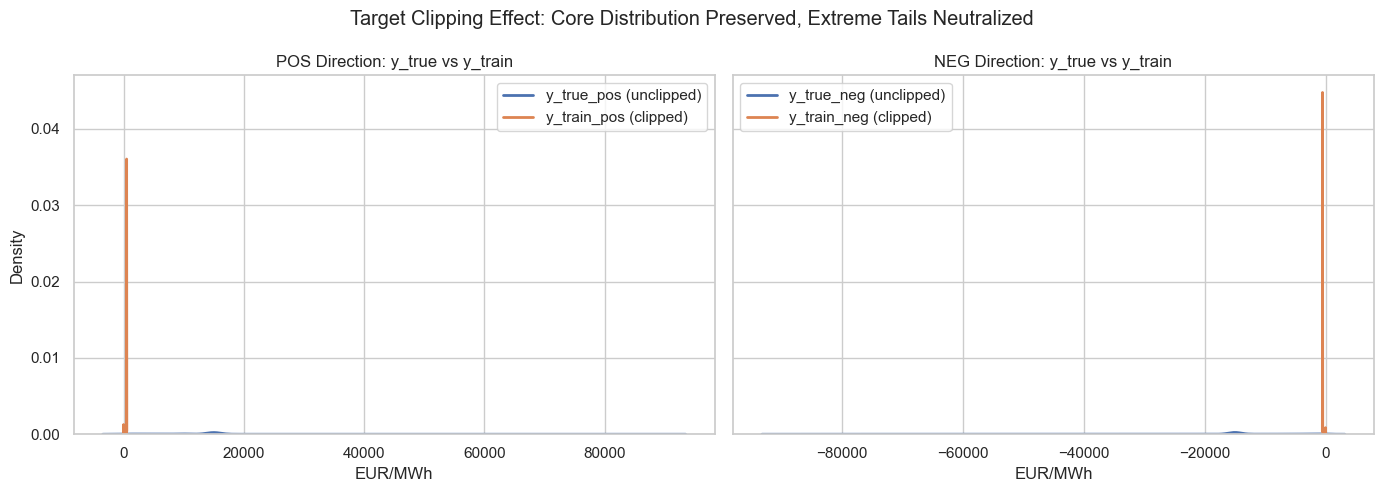

In [11]:
# Distribution overlay: y_true vs y_train (POS + NEG)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df.select([
    pl.col('afrr_marginal_price_y_true_pos').alias('y_true_pos'),
    pl.col('afrr_marginal_price_y_train_pos').alias('y_train_pos'),
    pl.col('afrr_marginal_price_y_true_neg').alias('y_true_neg'),
    pl.col('afrr_marginal_price_y_train_neg').alias('y_train_neg'),
]).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Positive direction
sns.kdeplot(plot_df['y_true_pos'].dropna(), ax=axes[0], label='y_true_pos (unclipped)', linewidth=2)
sns.kdeplot(plot_df['y_train_pos'].dropna(), ax=axes[0], label='y_train_pos (clipped)', linewidth=2)
axes[0].set_title('POS Direction: y_true vs y_train')
axes[0].set_xlabel('EUR/MWh')
axes[0].legend()

# Negative direction
sns.kdeplot(plot_df['y_true_neg'].dropna(), ax=axes[1], label='y_true_neg (unclipped)', linewidth=2)
sns.kdeplot(plot_df['y_train_neg'].dropna(), ax=axes[1], label='y_train_neg (clipped)', linewidth=2)
axes[1].set_title('NEG Direction: y_true vs y_train')
axes[1].set_xlabel('EUR/MWh')
axes[1].legend()

plt.suptitle('Target Clipping Effect: Core Distribution Preserved, Extreme Tails Neutralized')
plt.tight_layout()
plt.show()
